In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("car_fuel_efficiency_2026.csv")

## EDA


In [3]:
features = ['engine_displacement',
'horsepower',
'vehicle_weight',
'model_year',
'fuel_efficiency_mpg']

In [4]:
fuel_efficiency = df.fuel_efficiency_mpg.values

In [5]:
np.histogram(fuel_efficiency)

(array([  19,  157,  817, 1950, 2672, 2605, 1187,  499,   86,    8]),
 array([19.8 , 21.94, 24.08, 26.22, 28.36, 30.5 , 32.64, 34.78, 36.92,
        39.06, 41.2 ]))

<Axes: ylabel='Count'>

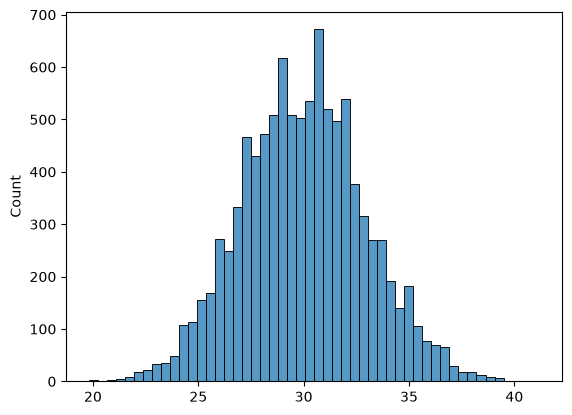

In [6]:
sns.histplot(fuel_efficiency, bins=50)

## Question 1


In [7]:
df_feat = df[features]

In [8]:
df_feat.isnull().sum()

engine_displacement      0
horsepower             877
vehicle_weight           0
model_year               0
fuel_efficiency_mpg      0
dtype: int64

## Question 2


In [9]:
df_feat.horsepower.median()

np.float64(254.0)

## Question 3

## Prepare and split the dataset

In [10]:
n = len(df_feat)
n_val = int(n*0.2)
n_test = int(n*0.2)
n_train = n - n_val - n_test

In [11]:
np.random.seed(42)

idx = np.arange(n)
np.random.shuffle(idx)

df_feat = df_feat.iloc[idx]

df_train = df_feat.iloc[idx[:n_train]]
df_val = df_feat.iloc[idx[n_train:n_train+n_val]]
df_test = df_feat.iloc[idx[n_train+n_val:]]

In [12]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
7217,2250,256.0,4440,2007,31.1
8291,2550,281.0,5010,2004,25.4
4607,2300,279.0,4230,1994,28.2
5114,2100,252.0,3990,2002,29.2
1859,2310,261.0,4040,1996,30.2


### Fillna with 0

In [13]:
def prepare_X(df):
    df = df.copy()
    df = df.fillna(0)
    X = df.values
    return X

In [14]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [15]:
y_train = df_train.fuel_efficiency_mpg
y_val = df_val.fuel_efficiency_mpg
y_test = df_test.fuel_efficiency_mpg

df_train.drop(columns="fuel_efficiency_mpg", inplace=True)
df_val.drop(columns="fuel_efficiency_mpg", inplace=True)
df_test.drop(columns="fuel_efficiency_mpg", inplace=True)

In [16]:
X_train = prepare_X(df_train)
w0, w = train_linear_regression(X_train, y_train)

In [17]:
def rmse(y_pred, y):
    se = (y_pred - y)**2
    mse = np.mean(se)
    rmse = np.sqrt(mse)
    return rmse 

In [18]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)

In [19]:
y_pred.shape

(2000,)

In [20]:
score = rmse(y_pred, y_val)
score

np.float64(2.1963699776123127)

### Fillna with mean

In [21]:
mean = df_train.horsepower.mean()
def prepare_X_mean(df):
    df = df.copy()
    df = df.fillna(mean)
    X = df.values
    return X

In [22]:
X_train_mean = prepare_X_mean(df_train)

In [23]:
X_train_mean.shape

(6000, 4)

In [24]:
w0_mean, w_mean = train_linear_regression(X_train_mean, y_train)

In [25]:
X_val_mean = prepare_X(df_val)
y_pred_mean = w0_mean + X_val.dot(w_mean)

In [26]:
score_mean = rmse(y_pred_mean, y_val)
score_mean

np.float64(2.2939561409772633)

## Question 4


In [27]:
def train_linear_regression_reg(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])

    XTX_inv = np.linalg.inv(XTX)
    w_full = XTX_inv.dot(X.T).dot(y)

    return w_full[0], w_full[1:]

In [28]:
param_list = [0, 0.01, 0.1, 1, 5, 10, 100]

In [29]:
scores = []
for r in param_list:
    w0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_pred, y_val)
    scores.append({
        "score": score,
        "r":r
    })

In [30]:
scores

[{'score': np.float64(2.1963699776123127), 'r': 0},
 {'score': np.float64(2.1963744285399143), 'r': 0.01},
 {'score': np.float64(2.2117130207720246), 'r': 0.1},
 {'score': np.float64(2.333850480077193), 'r': 1},
 {'score': np.float64(2.3941614531998043), 'r': 5},
 {'score': np.float64(2.404320553030399), 'r': 10},
 {'score': np.float64(2.414129421802818), 'r': 100}]

## Question 5


In [54]:
def split(df, seed):
    df = df.copy()
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)
    df = df.iloc[idx]
    df_train = df.iloc[idx[:n_train]]
    df_val = df.iloc[idx[n_train:n_train+n_val]]
    df_test = df.iloc[idx[n_train+n_val:]]

    return df_train, df_val, df_test
    

In [69]:
def target(df_train, df_val, df_test):
    y_train = df_train.fuel_efficiency_mpg
    y_val = df_val.fuel_efficiency_mpg
    y_test = df_test.fuel_efficiency_mpg

    return y_train, y_val, y_test
    

In [70]:
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
scores = []
for seed in seeds:
    df_train, df_val, df_test = split(df_features, seed)
    y_train, y_val, y_test = target(df_train, df_val, df_test)
    X_train = prepare_X(df_train.drop(columns="fuel_efficiency_mpg"))
    w0, w = train_linear_regression(X_train, y_train)
    X_val = prepare_X(df_val.drop(columns="fuel_efficiency_mpg"))
    y_pred = w0 + X_val.dot(w)
    score = rmse(y_pred, y_val)
    scores.append(score)
std = np.std(scores)
print(round(std, 3))

0.025


In [64]:
scores

[{'score': np.float64(2.2146612739159943), 'seed': 0},
 {'score': np.float64(2.2070062985402306), 'seed': 1},
 {'score': np.float64(2.2142436406639026), 'seed': 2},
 {'score': np.float64(2.196765103867851), 'seed': 3},
 {'score': np.float64(2.1663355491061296), 'seed': 4},
 {'score': np.float64(2.2048678048007972), 'seed': 5},
 {'score': np.float64(2.2665154155332283), 'seed': 6},
 {'score': np.float64(2.18527224954069), 'seed': 7},
 {'score': np.float64(2.1972083042895982), 'seed': 8},
 {'score': np.float64(2.2243155867225717), 'seed': 9}]

In [68]:
df_features.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


## Question 6

In [80]:
df_train, df_val, df_test = split(df_features, 9)
y_train, y_val, y_test = target(df_train, df_val, df_test)
y_train = pd.concat([y_train, y_val], ignore_index=True)
df_train = pd.concat([df_train, df_val], ignore_index=True)
X_train = prepare_X(df_train.drop(columns="fuel_efficiency_mpg"))
w0, w = train_linear_regression_reg(X_train, y_train, r=0.001)
X_test = prepare_X(df_test.drop(columns="fuel_efficiency_mpg"))
y_pred = w0 + X_test.dot(w)
score = rmse(y_pred, y_test)
print(round(score, 3))

2.181


In [73]:
df_train, df_val, df_test = split(df_features, 9)
df_train = pd.concat([df_train, df_val], ignore_index=True)
y_train, y_val, y_test = target(df_train, df_val, df_test)
y_train = pd.concat([y_train, y_val], ignore_index=True)
X_train = prepare_X(df_train.drop(columns="fuel_efficiency_mpg"))

In [78]:
y_test.shape

(2000,)